## Setup

In [73]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [74]:
from tapas_gmm_modified.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm_modified.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm_modified.policy.models.tpgmm
from tapas_gmm_modified.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm_modified.utils.logging import setup_logger  # noqa: F401
from tapas_gmm_modified.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
task = "GrabRedDrawer"
path = data_root / task / "demos"

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))

SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [76]:
gt_pose_config = {}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'static',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [77]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([173, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([173]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([173, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([173, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([173, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([173, 3, 256, 256]), device=cpu, dt

In [ ]:
tpgmm_config = TPGMMConfig(
    n_components=20,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,
    add_gripper_action=True,
    reg_shrink=1e-2,
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,
    #trans_cov_mask_t_pos_corr=False,
    em_steps=50,
    reg_init_diag=5e-4,  # 5
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    #gt_frames=[
    #    [0, 2,7],
    #    [0, 2,7],
    #    [0, 2,7],
    #    [0, 2,7],
    #]
    gt_frames=[
        [0, 7],
        [7],
        [7],
        [0, 7],
    ]
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    components_prop_to_len=True,
    velocity_threshold=0.001,
    repeat_final_step=10,
    repeat_first_step=10,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [79]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-17 20:50:29.559 | INFO     |  Fitting AutoTPGMM
2025-08-17 20:50:29.559 | INFO     |  Segmenting trajectories


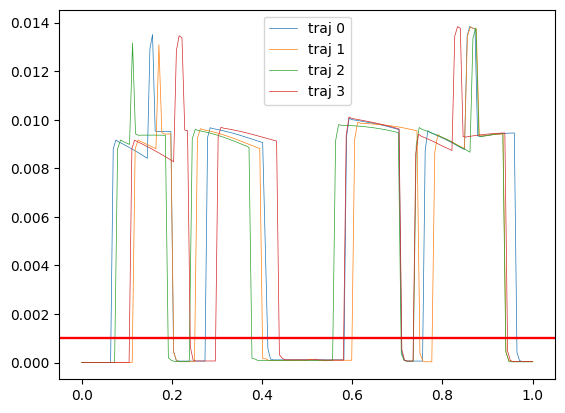

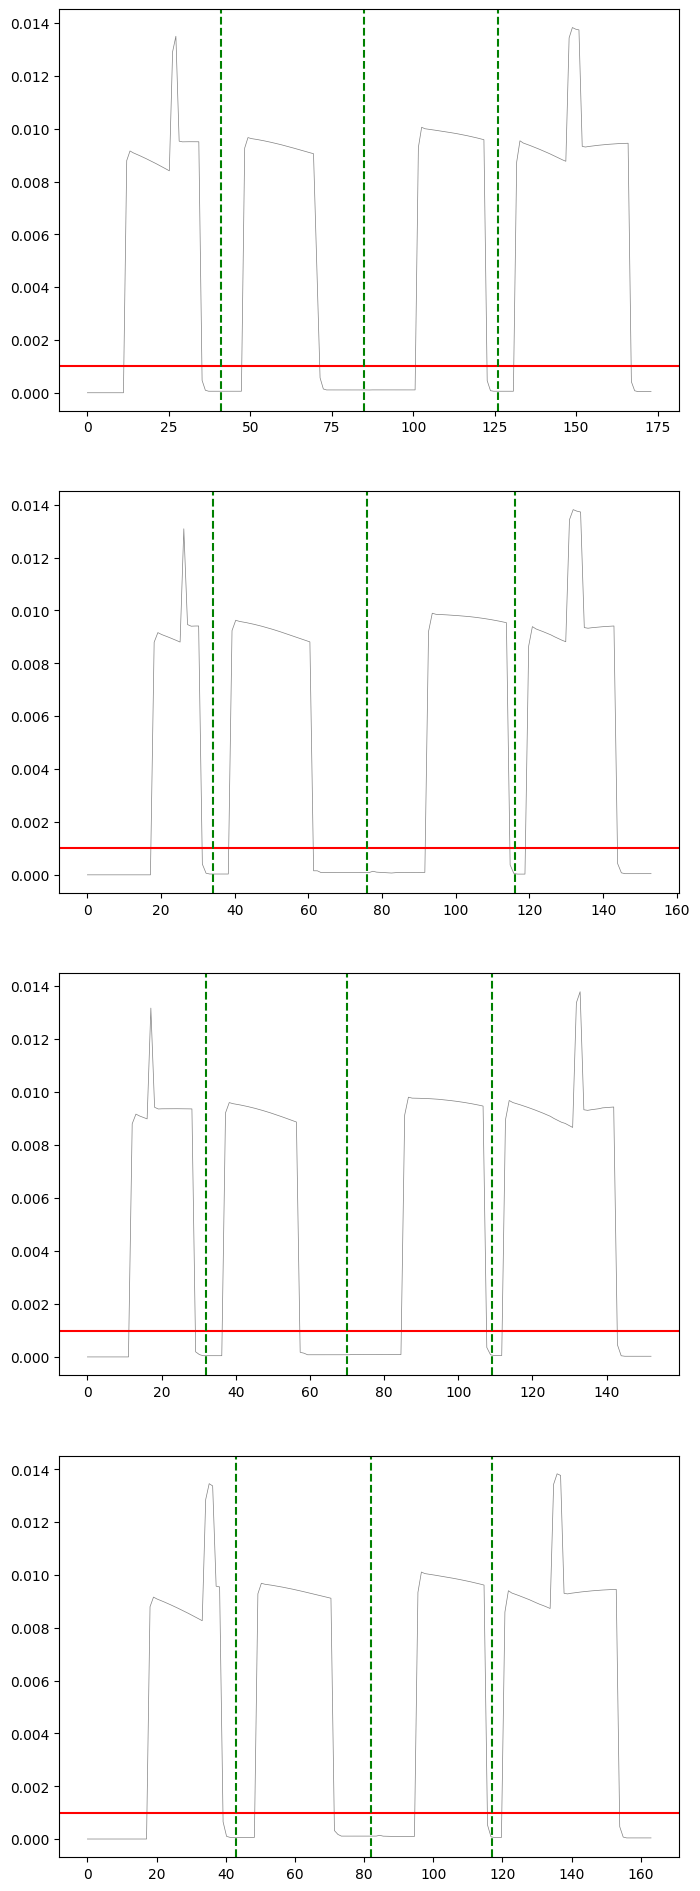

2025-08-17 20:50:29.765 | INFO     |  Creating segement of demos.
2025-08-17 20:50:29.768 | INFO     |  Creating segement of demos.
2025-08-17 20:50:29.770 | INFO     |  Creating segement of demos.
2025-08-17 20:50:29.772 | INFO     |  Creating segement of demos.
2025-08-17 20:50:29.774 | INFO     |  ... created 4 segments
2025-08-17 20:50:29.774 | INFO     |    Fitting candidate frame 1/10
2025-08-17 20:50:29.774 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-17 20:50:29.821 | INFO     |    Fitting candidate frame 2/10
2025-08-17 20:50:29.821 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-17 20:50:29.898 | INFO     |    Fitting candidate frame 3/10
2025-08-17 20:50:29.899 | INFO     |    Creating partial frame view of demos.


...

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

((array([[1.06e+16, 1.19e+16, 1.30e+16, 1.38e+16, 1.42e+16, 1.42e+16,
          1.38e+16, 1.30e+16, 1.19e+16, 1.06e+16, 9.11e+15, 7.62e+15,
          6.19e+15, 4.88e+15, 3.73e+15, 2.77e+15, 2.00e+15, 1.40e+15,
          9.52e+14, 6.28e+14, 4.02e+14, 2.23e+14, 9.37e+13, 3.13e+13,
          8.33e+12, 1.78e+12, 3.04e+11, 4.20e+10, 4.70e+09, 4.27e+08,
          3.18e+07, 1.94e+06, 9.75e+04, 4.06e+03, 2.47e+00, 3.34e-01,
          3.87e-02, 3.33e-03, 2.15e-04, 1.03e-05, 3.72e-07, 1.00e-08,
          3.38e-09, 1.14e-09, 3.67e-10, 1.15e-10, 3.49e-11, 1.00e-11,
          2.79e-12, 7.55e-13, 1.98e-13, 5.06e-14, 1.25e-14, 3.00e-15,
          7.00e-16, 8.88e+15, 1.00e+16, 1.09e+16, 1.16e+16, 1.20e+16,
          1.20e+16, 1.16e+16, 1.09e+16, 1.00e+16, 8.88e+15, 7.66e+15,
          6.41e+15, 5.20e+15, 4.10e+15, 3.14e+15, 2.33e+15, 1.68e+15,
          1.18e+15, 8.00e+14, 5.28e+14, 3.38e+14, 2.10e+14, 1.27e+14,
          7.43e+13, 4.22e+13, 2.33e+13, 1.25e+13, 6.49e+12, 3.28e+12,
          1.61e+12, 

In [80]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,)) # FittingStage.EM_HMM))


2025-08-17 20:50:34.540 | INFO     |  Did not specify time_based, deciding automatically.


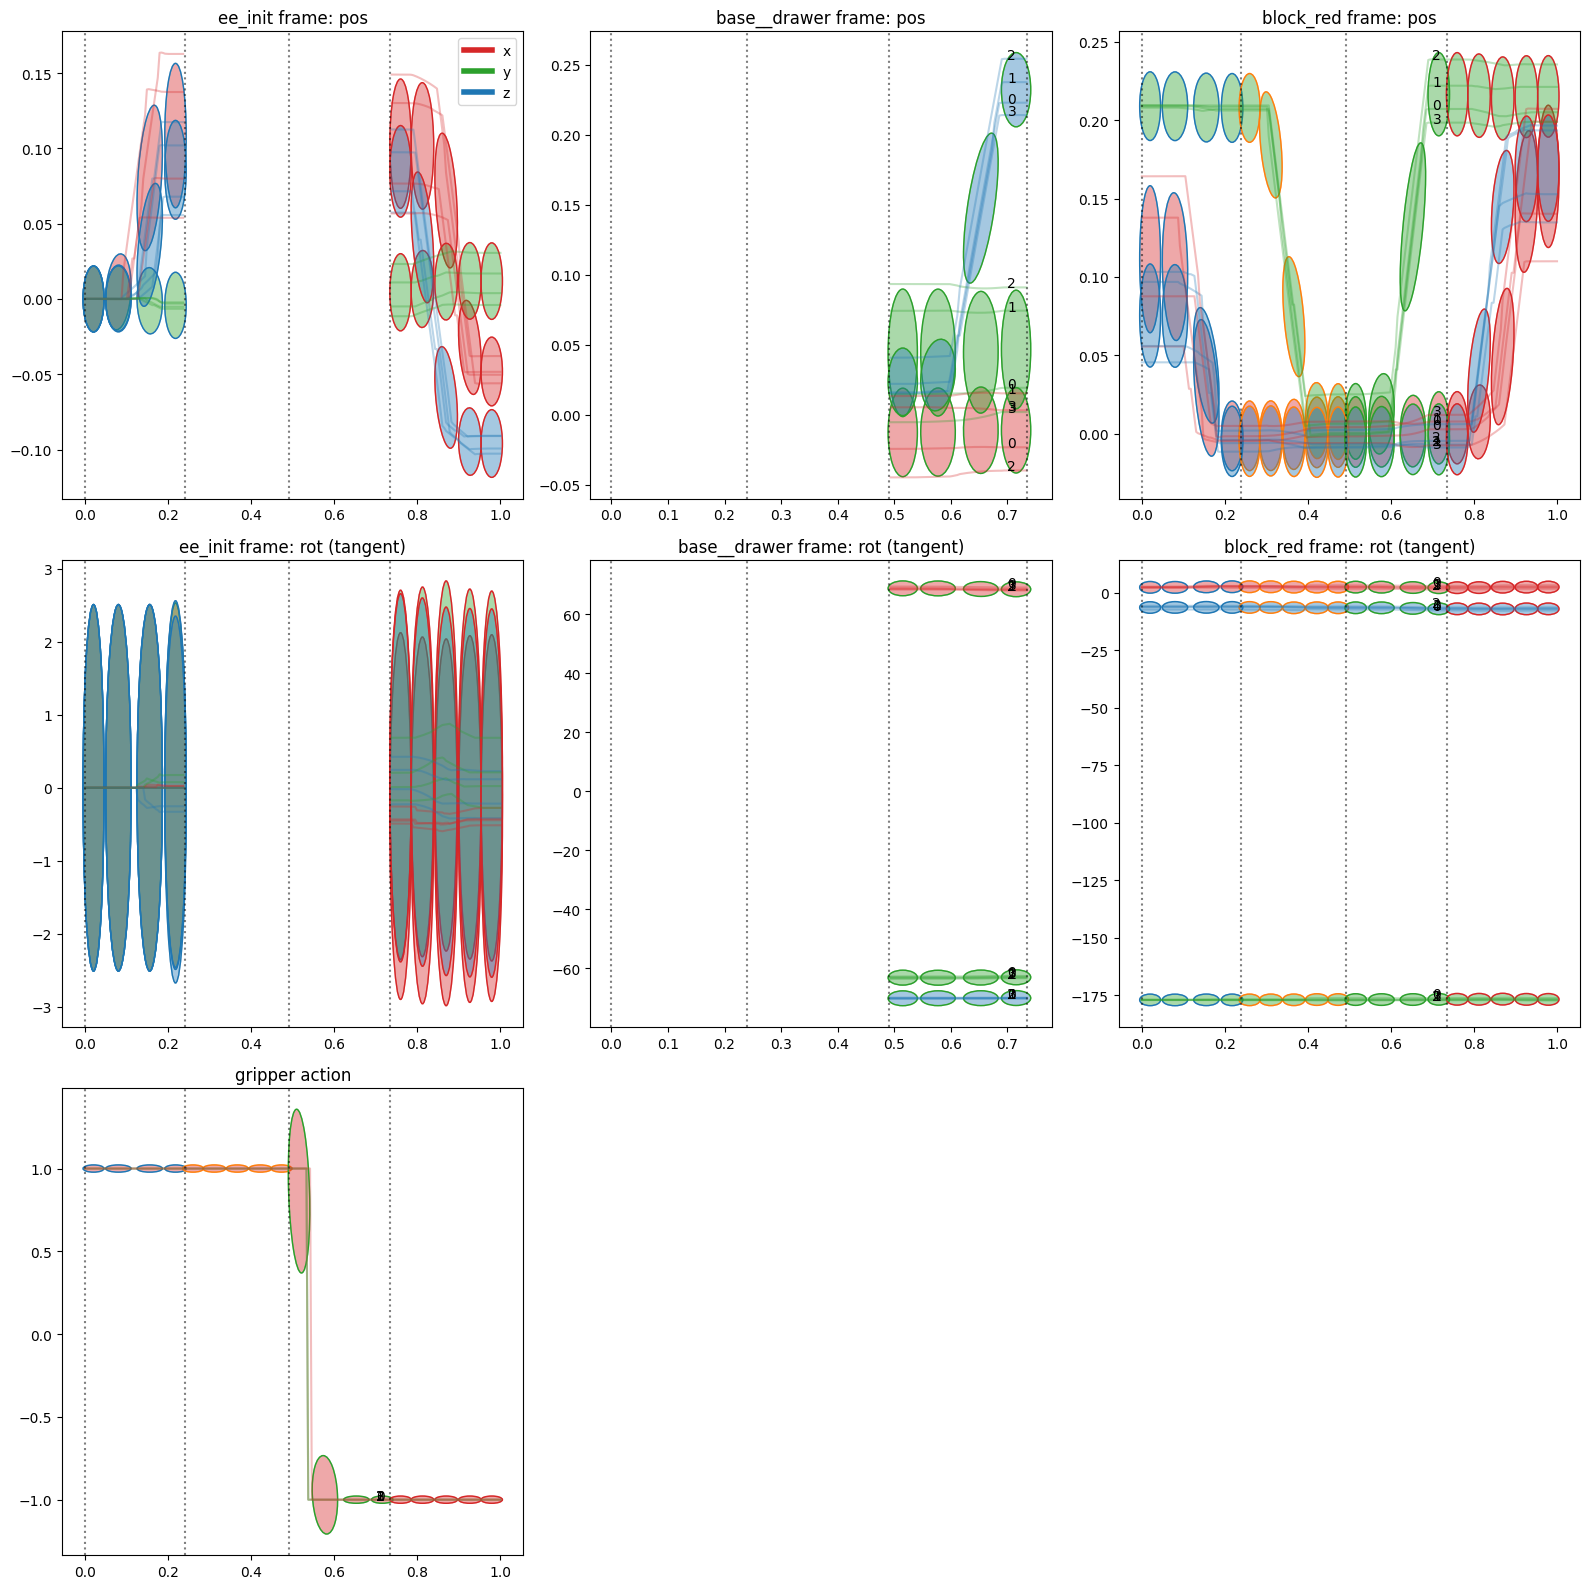

In [81]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [82]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-17 20:50:35.589 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/4 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[9.67e-025, 2.31e-025, 5.25e-026, 1.12e-026, 2.22e-027, 3.99e-028,
          6.43e-029, 9.17e-030, 1.13e-030, 1.20e-031, 1.07e-032, 7.89e-034,
          4.74e-035, 2.28e-036, 8.67e-038, 2.55e-039, 5.73e-041, 9.65e-043,
          1.20e-044, 1.08e-046, 6.95e-049, 2.08e-051, 4.02e-054, 4.75e-057,
          1.70e-060, 6.76e-065, 2.13e-070, 4.84e-077, 7.52e-085, 7.65e-094,
          4.85e-104, 1.82e-115, 3.86e-128, 4.60e-145, 6.38e-162, 5.93e-180,
          2.94e-199, 6.70e-220, 6.04e-242, 1.85e-265, 1.66e-290, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 1.92e-024, 6.96e-025, 2.28e-025, 6.67e-026, 1.71e-026,
          3.81e-027, 7.21e-028, 1.14e-028, 1.49e-029, 1.58e-030, 1.34e-031,
          8.87e-033, 4.53e-034, 1.76e-035, 5.08e-037, 1.08e-038, 1.64e-040,
          1.78e-042, 1.35e-044, 7.00e-047, 2.45e-049, 5.70e-052, 8.65e-055,
          8.

2025-08-17 20:50:39.835 | INFO     |  Did not specify time_based, deciding automatically.


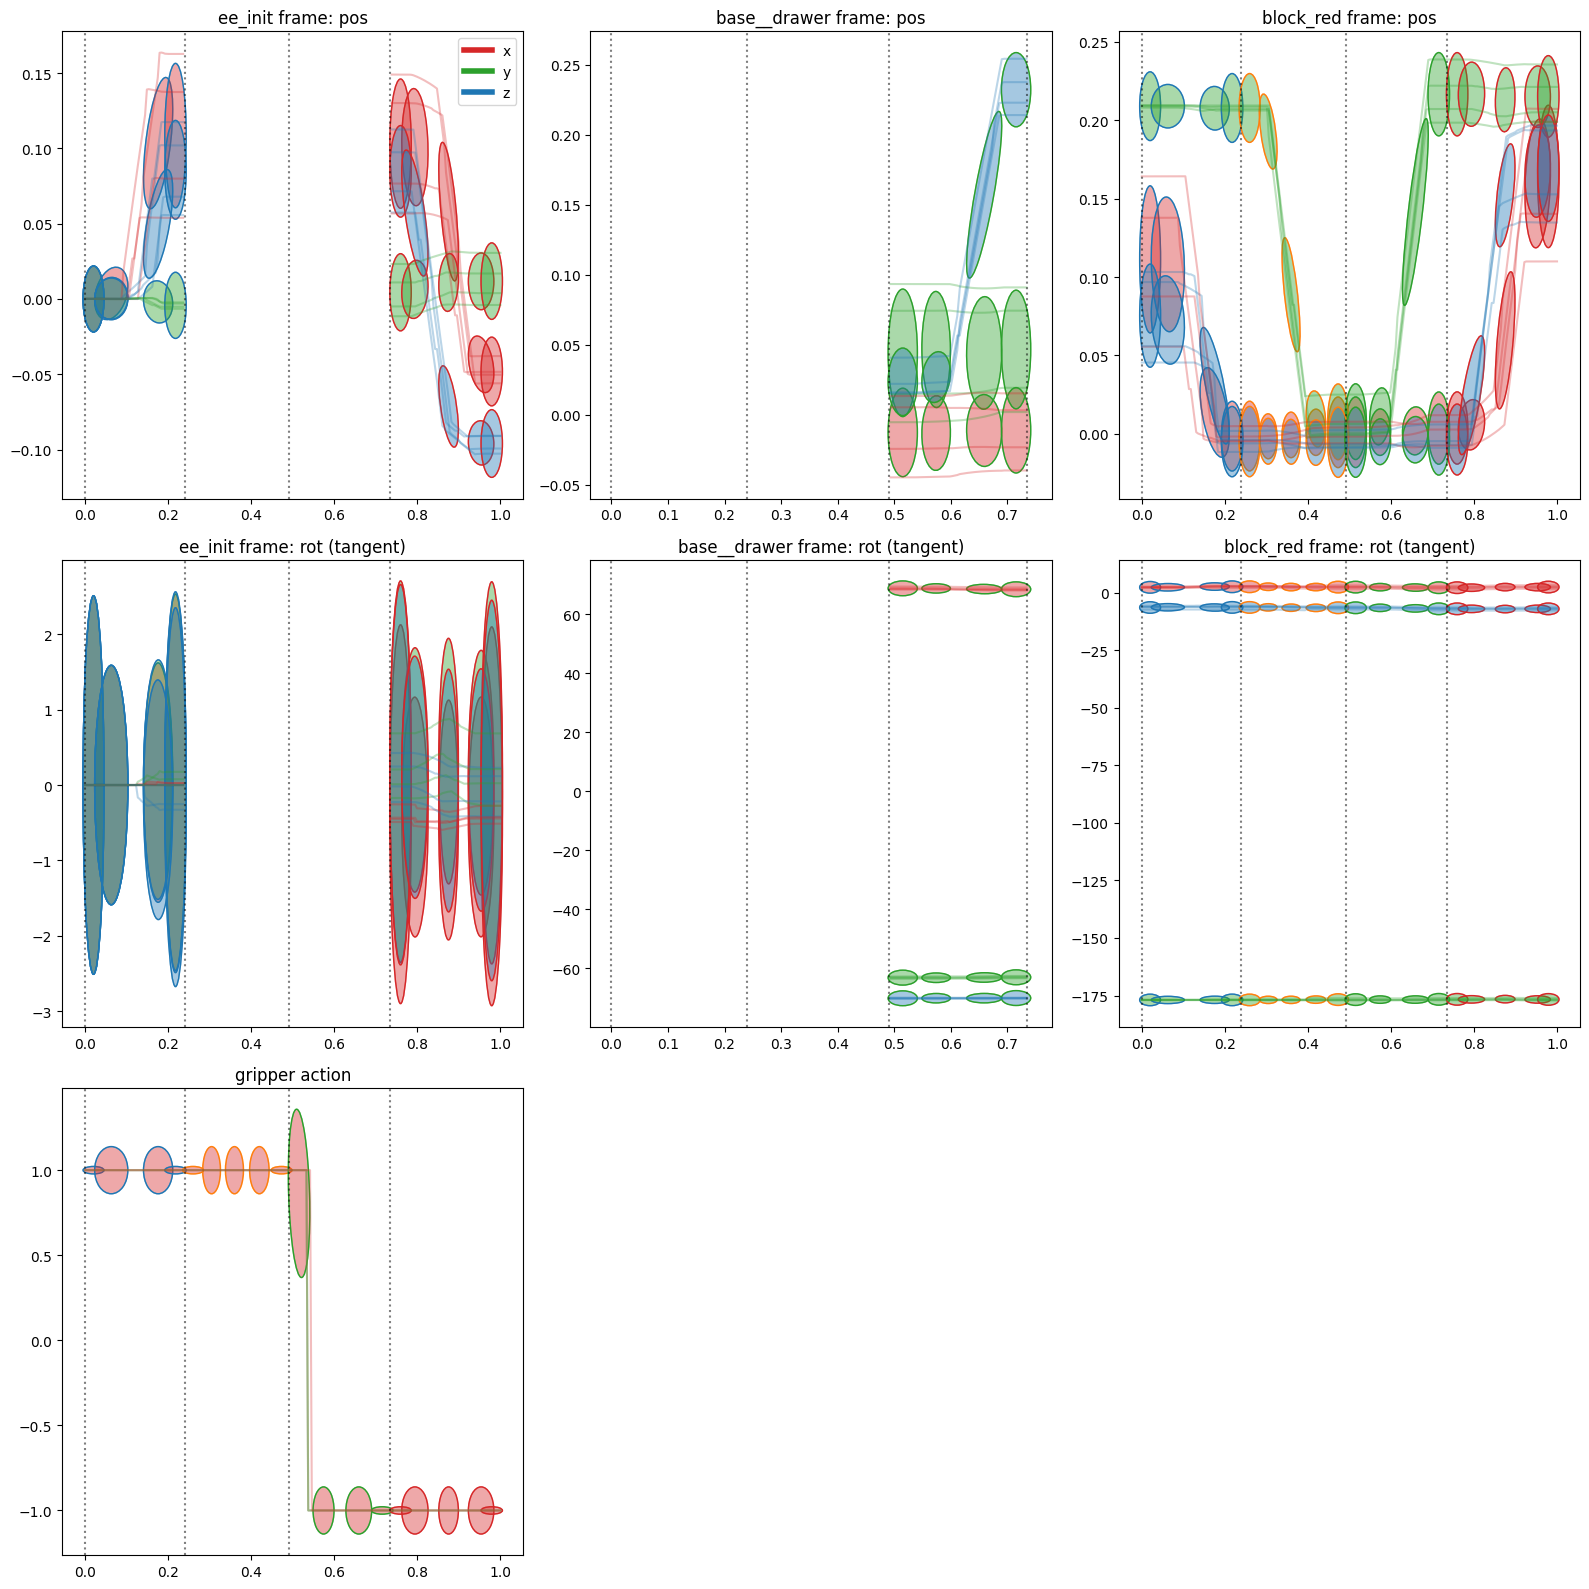

In [83]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

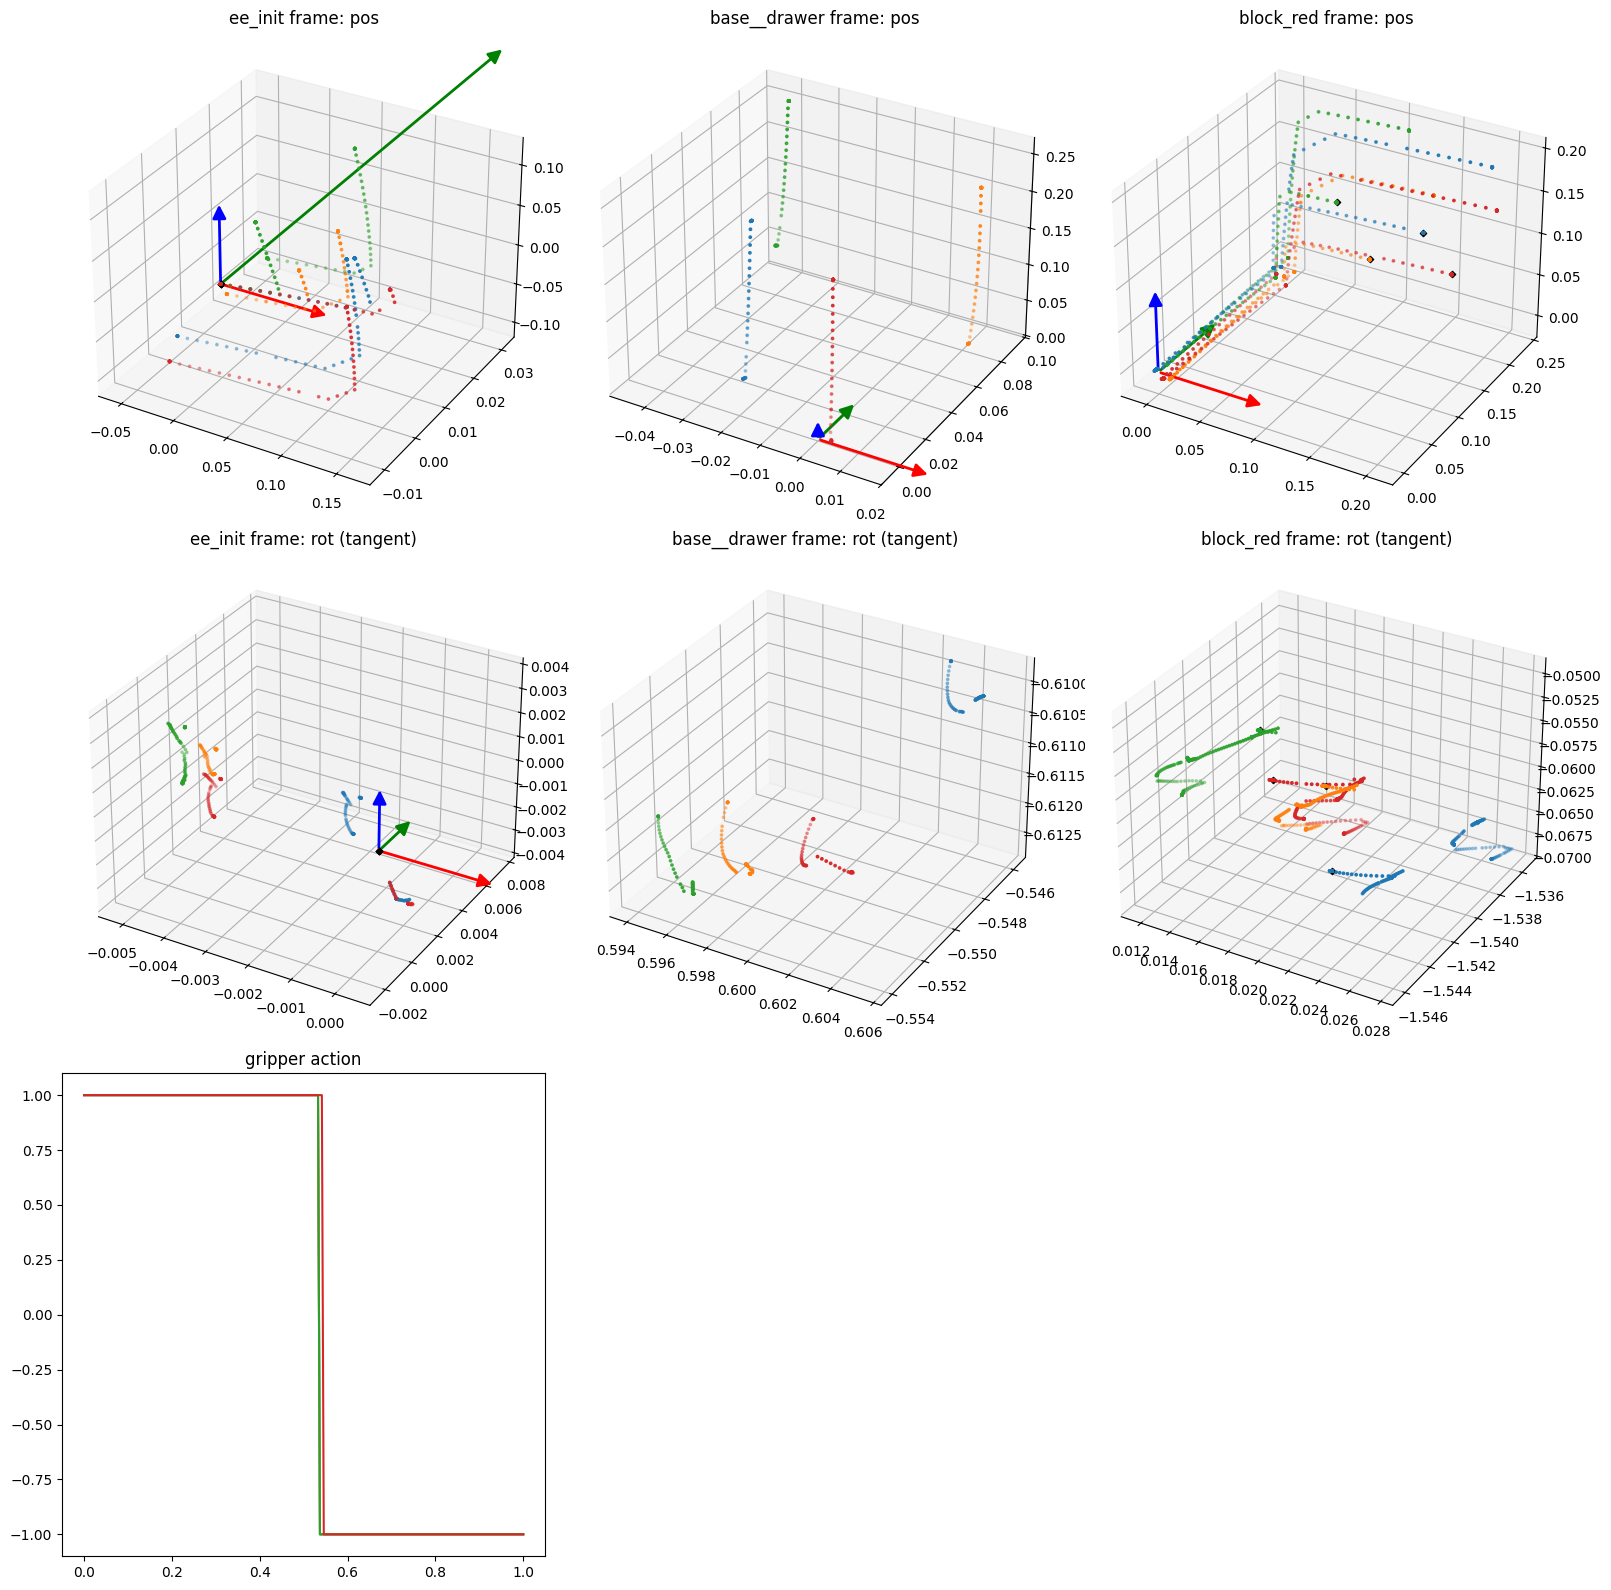

In [84]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=False,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False, time_based=False)

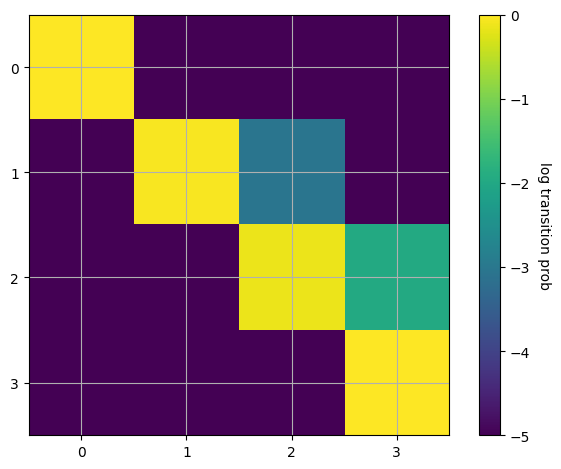

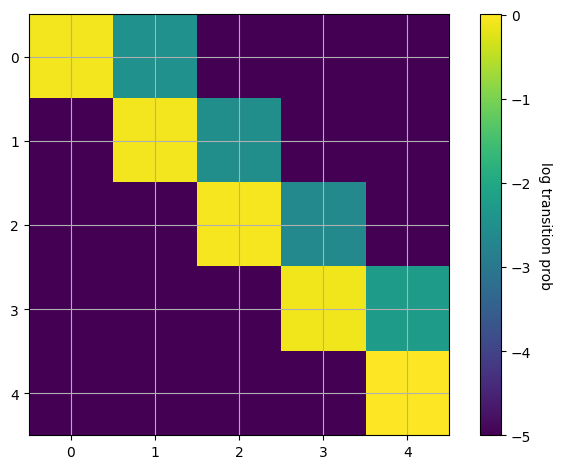

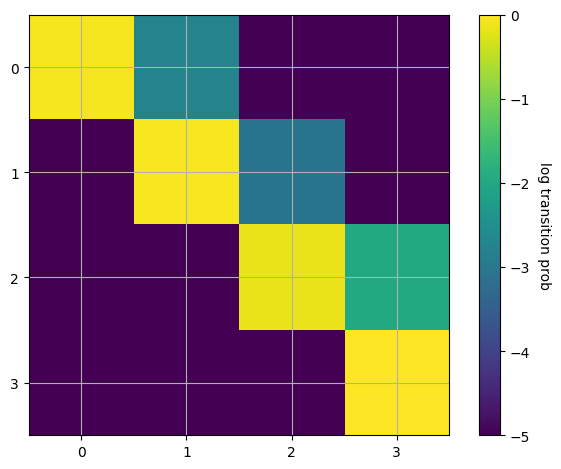

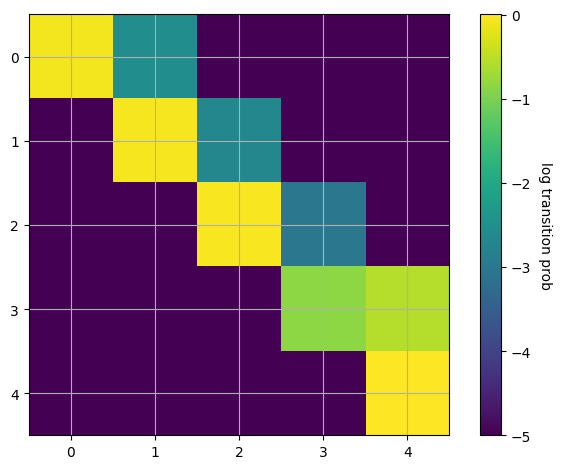

In [85]:
atpgmm.plot_hmm_transition_matrix()

In [86]:
atpgmm.to_disk(data_root / task / 'demos_gmm_policy-release.pt')

In [87]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm_modified.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-17 20:50:55.495 | INFO     |  Caculated segment transition probabilities: (array([[0.26]]), array([[0.28]]), array([[0.24]]))
2025-08-17 20:50:55.495 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/4 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-17 20:50:55.563 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/4 [00:00<?, ?it/s]

...

Joining marginals:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-17 20:50:55.675 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/4 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/4 [00:00<?, ?it/s]

GMR:   0%|          | 0/4 [00:00<?, ?it/s]

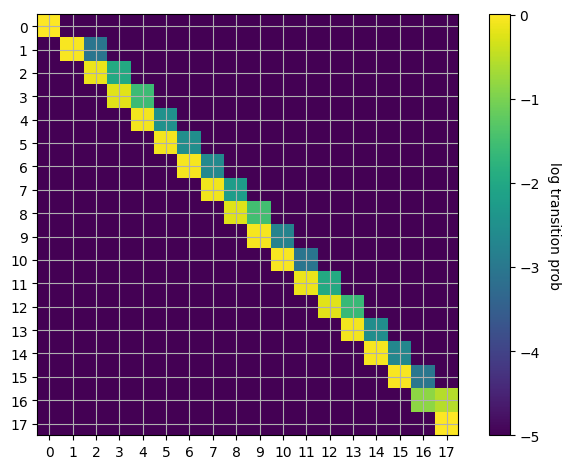

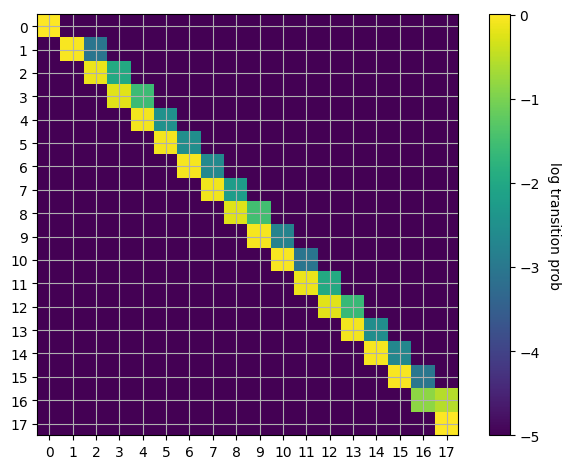

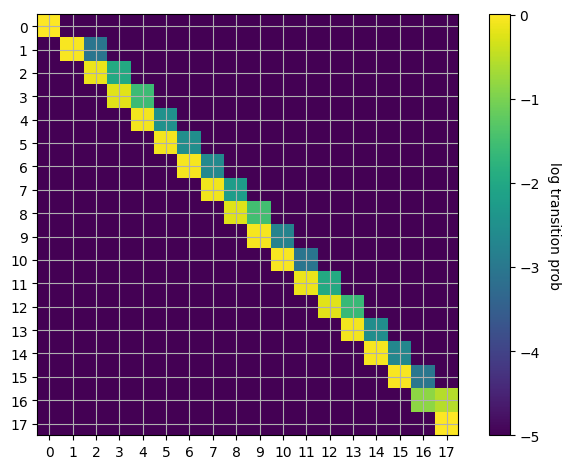

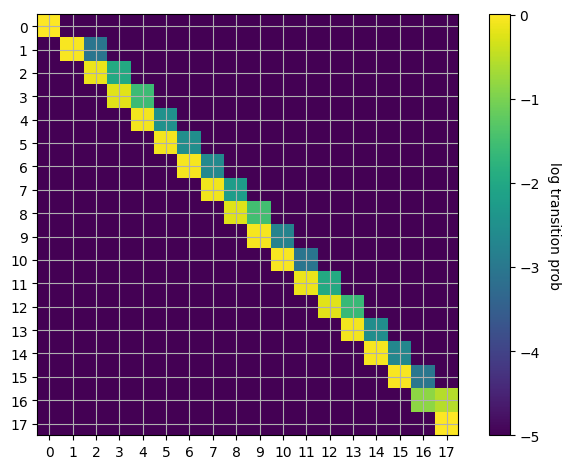

In [88]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-17 20:50:59.240 | INFO     |  Taking frame origins from demos.


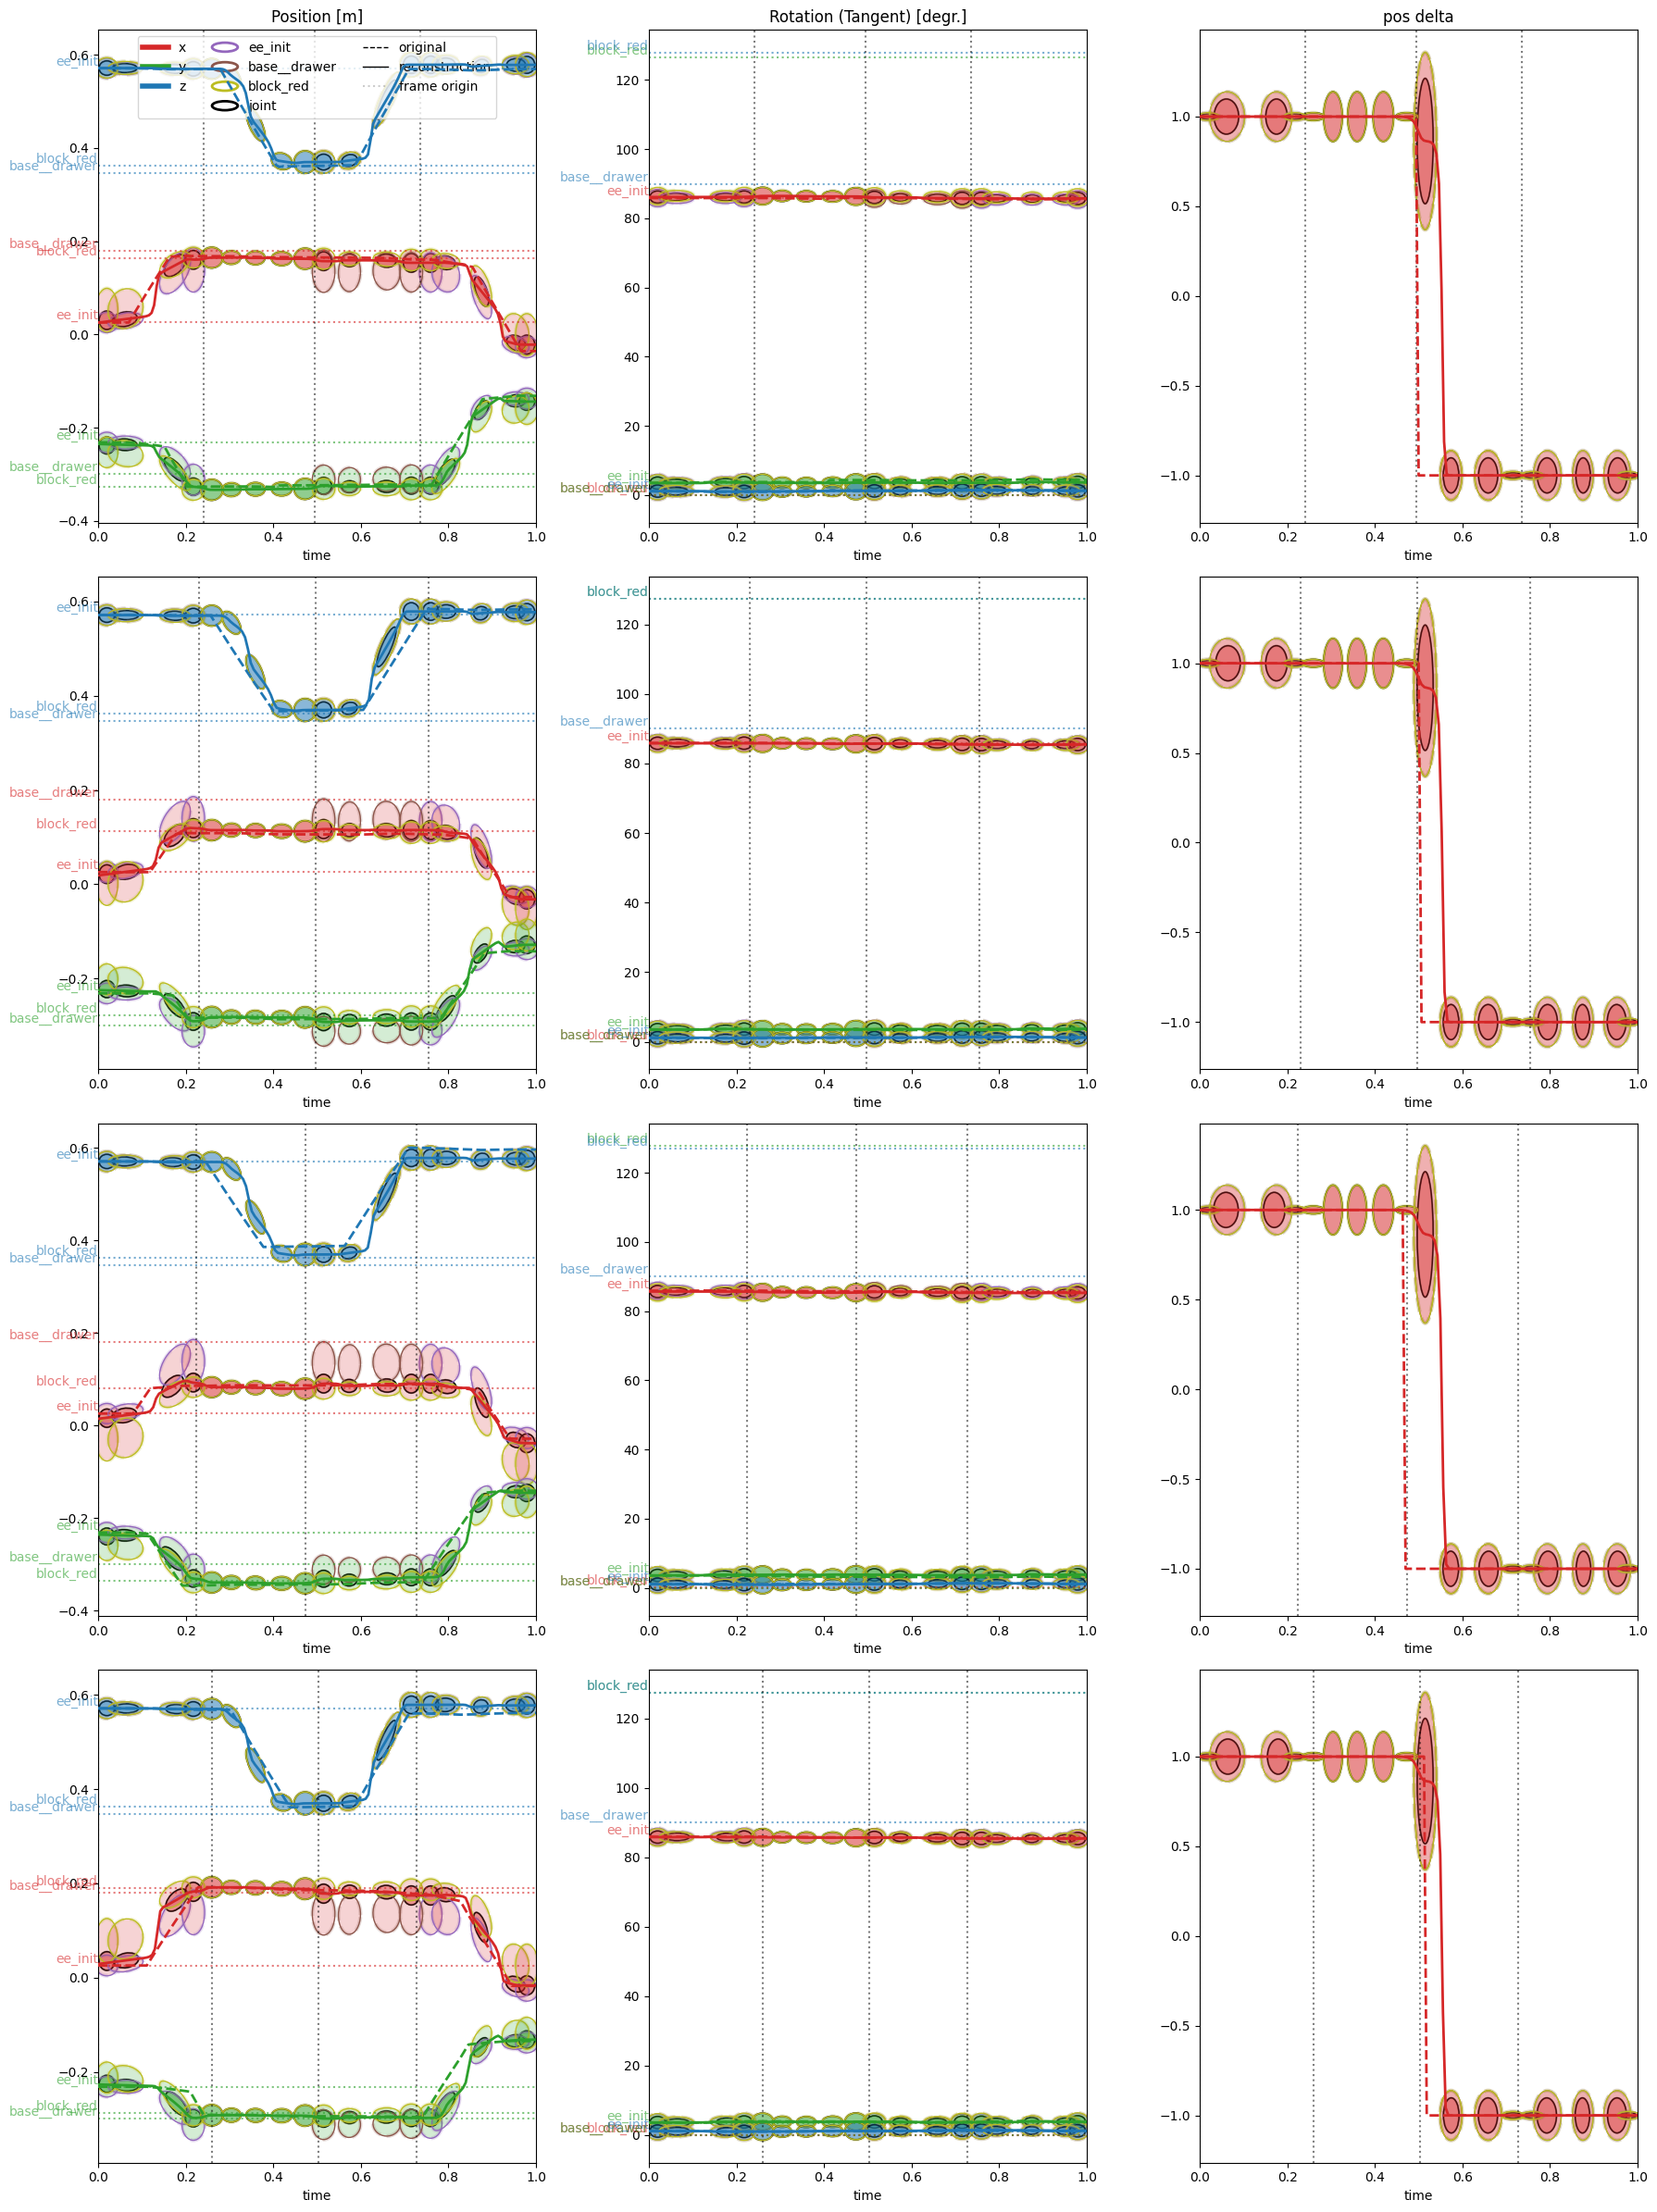

In [89]:

atpgmm.plot_reconstructions(
    seg_trans_marg_container, cascaded_hmms, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=True, equal_aspect=False, per_segment=False)


In [90]:
atpgmm.plot_reconstructions(
    seg_trans_marginals, seg_joint_models, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=False, equal_aspect=True, per_segment=False)


IndexError: tuple index out of range